# Training curves — publication figure

Renders all metrics in `Training_logs/` as a despined grid figure.

**Data note.** The W&B grouped export provides `MEAN`, `__MIN`, `__MAX` across seeds.
Standard errors are *not* recoverable from a min-max range, so the shaded band is the
**min-max envelope across seeds** and is labelled as such. To plot mean +/- SEM instead,
re-export the runs ungrouped (one CSV per seed) and swap in `band_from_seeds()` at the
bottom of this notebook.

In [1]:
# ---------------------------------------------------------------- imports
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

## 1. Configuration

In [2]:
# ---------------------------------------------------------------- paths
LOG_DIR = Path("results/Training_logs")
OUT_DIR = Path("results/plots")
OUT_DIR.mkdir(exist_ok=True)

# ---------------------------------------------------------------- palette
# Nature Publishing Group house palette (ggsci::pal_npg, "nrc").
NPG = {
    "red":    "#E64B35",
    "cyan":   "#4DBBD5",
    "teal":   "#00A087",
    "navy":   "#3C5488",
    "salmon": "#F39B7F",
    "steel":  "#8491B4",
    "green":  "#91D1C2",
    "maroon": "#7E6148",
    "grey":   "#B09C85",
}

# ---------------------------------------------------------------- figure geometry
# Nature: single column 89 mm, double column 183 mm. Text >= 5 pt at final size.
MM = 1 / 25.4
DOUBLE_COL = 183 * MM
BASE_FONT = 7

# ---------------------------------------------------------------- behaviour
N_SEEDS = 7          # grouped runs contributing to the min-max envelope
SMOOTH_WINDOW = 1    # rolling-mean window in steps; 1 = raw, no smoothing
BAND_ALPHA = 0.20
DPI = 600

In [3]:
# ---------------------------------------------------------------- panel spec
# One entry per subplot, in reading order. `col` is the W&B mean-column stem;
# MIN/MAX columns are derived by suffixing "__MIN" / "__MAX".
PANELS = [
    dict(file="training_rewards.csv",     col="Grouped runs - train/reward",
         title="Episode return",     ylabel="Return",            color=NPG["navy"]),
    dict(file="training_consumption.csv", col="Grouped runs - train/consumption",
         title="Consumption",        ylabel="Items consumed",    color=NPG["teal"]),
    dict(file="training_distance.csv",    col="Grouped runs - train/distance",
         title="Distance travelled", ylabel="Distance (a.u.)",   color=NPG["cyan"]),
    dict(file="training_actor_loss.csv",  col="Grouped runs - train/actor_loss",
         title="Actor loss",         ylabel="Loss",              color=NPG["red"]),
    dict(file="training_critic_loss.csv", col="Grouped runs - train/critic_loss",
         title="Critic loss",        ylabel="Loss",              color=NPG["salmon"],
         logy=True),
    dict(file="training_entropy.csv",     col="Grouped runs - train/entropy",
         title="Policy entropy",     ylabel="Entropy (nats)",    color=NPG["steel"]),
]

NCOLS = 3
NROWS = int(np.ceil(len(PANELS) / NCOLS))

## 2. Style

In [4]:
def set_journal_style():
    """Apply Nature-style rcParams. Idempotent; call once per session."""
    mpl.rcParams.update({
        # --- typography -------------------------------------------------
        "font.family":       "sans-serif",
        "font.sans-serif":   ["Arial", "Helvetica", "DejaVu Sans"],
        "font.size":         BASE_FONT,
        "axes.titlesize":    BASE_FONT + 1,
        "axes.labelsize":    BASE_FONT,
        "xtick.labelsize":   BASE_FONT - 1,
        "ytick.labelsize":   BASE_FONT - 1,
        "legend.fontsize":   BASE_FONT - 1,
        "axes.titleweight":  "bold",
        # --- despine ----------------------------------------------------
        "axes.spines.top":   False,
        "axes.spines.right": False,
        # --- lines and ticks -------------------------------------------
        "axes.linewidth":    0.6,
        "lines.linewidth":   1.0,
        "xtick.direction":   "out",
        "ytick.direction":   "out",
        "xtick.major.width": 0.6,
        "ytick.major.width": 0.6,
        "xtick.major.size":  2.5,
        "ytick.major.size":  2.5,
        # --- output -----------------------------------------------------
        "figure.dpi":        150,
        "savefig.dpi":       DPI,
        "savefig.bbox":      "tight",
        "savefig.pad_inches": 0.02,
        "pdf.fonttype":      42,   # embed as TrueType, not Type 3
        "ps.fonttype":       42,
        "axes.grid":         False,
        "legend.frameon":    False,
    })


set_journal_style()

## 3. Data loading

In [5]:
def load_metric(spec, log_dir=LOG_DIR, smooth=SMOOTH_WINDOW):
    """Read one W&B grouped-export CSV.

    Returns
    -------
    step, mean, lo, hi : 1-D float arrays with NaN rows dropped.
    """
    df = pd.read_csv(log_dir / spec["file"])
    cols = ["Step", spec["col"], spec["col"] + "__MIN", spec["col"] + "__MAX"]
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise KeyError(f"{spec['file']}: missing columns {missing}")

    df = df[cols].apply(pd.to_numeric, errors="coerce").dropna().sort_values("Step")

    if smooth and smooth > 1:
        df[cols[1:]] = df[cols[1:]].rolling(smooth, min_periods=1, center=True).mean()

    return (df[cols[0]].to_numpy(), df[cols[1]].to_numpy(),
            df[cols[2]].to_numpy(), df[cols[3]].to_numpy())

## 4. Plotting

In [6]:
def draw_panel(ax, spec):
    """Draw a single mean line with a shaded across-seed envelope."""
    step, mean, lo, hi = load_metric(spec)

    ax.fill_between(step, lo, hi, color=spec["color"],
                    alpha=BAND_ALPHA, linewidth=0, zorder=1)
    ax.plot(step, mean, color=spec["color"], zorder=2)

    ax.set_title(spec["title"], pad=4)
    ax.set_ylabel(spec["ylabel"], labelpad=2)
    ax.set_xlabel("Training step", labelpad=2)
    ax.set_xlim(step.min(), step.max())
    if spec.get("logy"):
        ax.set_yscale("log")
    ax.margins(x=0)
    return ax


def make_grid(panels=PANELS, nrows=NROWS, ncols=NCOLS):
    """Assemble the full grid figure."""
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(DOUBLE_COL, DOUBLE_COL * 0.52),
        constrained_layout=True,
    )
    axes = np.atleast_1d(axes).ravel()

    for ax, spec in zip(axes, panels):
        draw_panel(ax, spec)
    for ax in axes[len(panels):]:          # blank any unused cell
        ax.set_visible(False)

    # Panel letters (a, b, c, ...) as required by most journals.
    for letter, ax in zip("abcdefghij", axes[:len(panels)]):
        ax.text(-0.22, 1.10, letter, transform=ax.transAxes,
                fontsize=BASE_FONT + 2, fontweight="bold", va="top", ha="left")

    handles = [
        Line2D([], [], color="0.25", lw=1.0, label="Mean across seeds"),
        Patch(facecolor="0.25", alpha=BAND_ALPHA, linewidth=0,
              label=f"Min-max across {N_SEEDS} seeds"),
    ]
    fig.legend(handles=handles, loc="lower center", ncol=2,
               bbox_to_anchor=(0.5, -0.04))
    return fig

## 5. Render and save

saved -> /Users/charithapalika/Desktop/Lab projects/Appetite modelling/FoodRL/FoodRL_cleaned_copies/plots


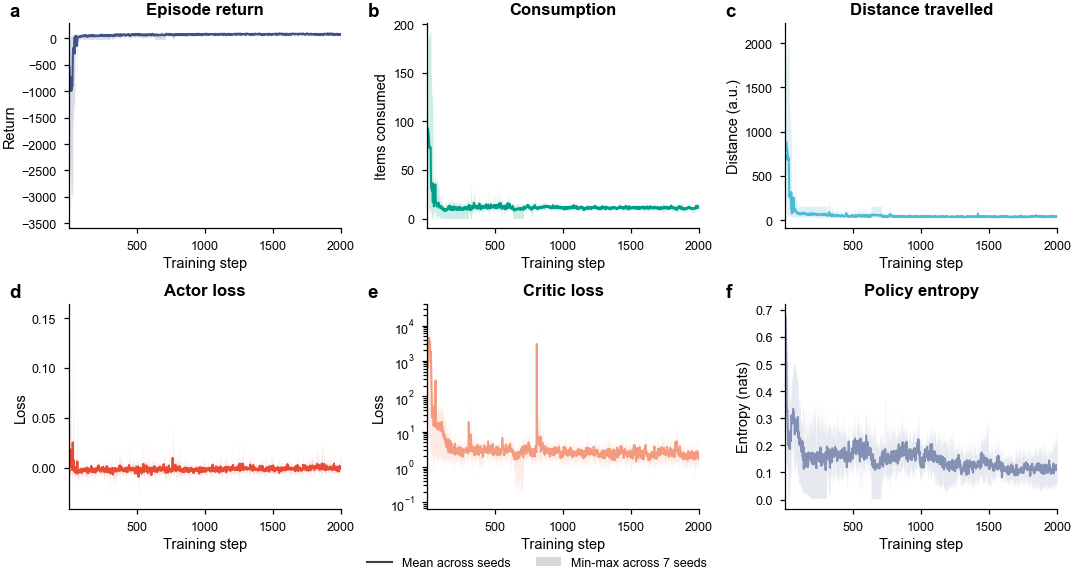

In [7]:
fig = make_grid()

for ext in ("png", "pdf", "svg"):
    fig.savefig(OUT_DIR / f"training_curves_grid.{ext}")

print("saved ->", OUT_DIR.resolve())
plt.show()

## 6. Optional — true mean +/- SEM

If you re-export the runs **ungrouped** (one CSV per seed, e.g.
`Training_logs/per_seed/reward_seed{0,3,7,27,42,64,107}.csv`), this replaces the
min-max envelope with a proper standard error of the mean. Swap `load_metric` for
`load_metric_seeds` inside `draw_panel` and update the legend label.

In [8]:
def load_metric_seeds(pattern, value_col, step_col="Step", log_dir=LOG_DIR):
    """Aggregate per-seed CSVs into mean +/- SEM.

    Parameters
    ----------
    pattern : glob relative to `log_dir`, one file per seed.
    value_col : name of the metric column within each per-seed file.
    """
    files = sorted(Path(log_dir).glob(pattern))
    if not files:
        raise FileNotFoundError(f"no files match {pattern!r} in {log_dir}")

    wide = pd.concat(
        [pd.read_csv(f).set_index(step_col)[value_col].rename(f.stem) for f in files],
        axis=1,
    ).sort_index()

    step = wide.index.to_numpy()
    mean = wide.mean(axis=1).to_numpy()
    sem = wide.std(axis=1, ddof=1).to_numpy() / np.sqrt(wide.notna().sum(axis=1).to_numpy())
    return step, mean, mean - sem, mean + sem